# **Langkah 1: Pre-Processing Data**

###**1.1 Load Dataset**

In [ ]:
df = pd.read_parquet(DATASET_PATH)

print(f"Dataset berhasil diload!")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print(f"Penggunaan Memori: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset berhasil diload!
Total rows: 46,776,700
Total columns: 40
Penggunaan Memori: 10599.42 MB


###**1.2 Inspeksi Awal**

1.2.1 Cek Kolom dan Tipe Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46776700 entries, 0 to 3845
Data columns (total 40 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Header_Length    float32
 1   Protocol Type    Int32  
 2   Time_To_Live     float32
 3   Rate             float32
 4   fin_flag_number  float32
 5   syn_flag_number  float32
 6   rst_flag_number  float32
 7   psh_flag_number  float32
 8   ack_flag_number  float32
 9   ece_flag_number  float32
 10  cwr_flag_number  float32
 11  ack_count        Int32  
 12  syn_count        Int32  
 13  fin_count        Int32  
 14  rst_count        Int32  
 15  HTTP             float32
 16  HTTPS            float32
 17  DNS              float32
 18  Telnet           float32
 19  SMTP             float32
 20  SSH              float32
 21  IRC              float32
 22  TCP              float32
 23  UDP              float32
 24  DHCP             float32
 25  ARP              float32
 26  ICMP             float32
 27  IGMP             fl

1.2.2 Distribusi Kelas (34 Kelas Individual)

In [ ]:
label_col = 'Label' # Mendefinisikan ulang label_col untuk konteks ini
print(f"Distribusi Kelas (34 Serangan Individual):")
class_counts = df[label_col].value_counts()
print(class_counts)

Distribusi Kelas (34 Serangan Individual):
Label
DDoS-ICMP_Flood            7200501
DDoS-UDP_Flood             5412231
DDoS-TCP_Flood             4497649
DDoS-PSHACK_Flood          4094772
DDoS-SYN_Flood             4059179
DDoS-RSTFIN_Flood          4045279
DDoS-SynonymousIP_Flood    3598133
DoS-UDP_Flood              3072993
DoS-TCP_Flood              2671430
DoS-SYN_Flood              2028836
Benign_Traffic             1098191
Mirai-Greeth_Flood          991834
Mirai-UDP_Plain             890574
Mirai-Greip_Flood           751646
DDoS-ICMP_Fragmentation     452490
Vulnerability_Scan          373351
MITM_ARP_Spoofing           307560
DDoS-UDP_Fragmentation      286925
DDoS-ACK_Fragmentation      285075
DNS_Spoofing                178898
Recon-Host_Discovery        134378
Recon-OS_Scan                98259
Recon-Port_Scan              82284
DoS-HTTP_Flood               71861
DDoS-HTTP_Flood              28790
DDoS-Slow_Loris              23426
Dictionary_Brute_Force       13064
Browse

In [ ]:
print(f"Persentase Kelas:")
class_pct = (class_counts / len(df) * 100).round(4)
print(class_pct)

Persentase Kelas:
Label
DDoS-ICMP_Flood            15.3933
DDoS-UDP_Flood             11.5704
DDoS-TCP_Flood              9.6151
DDoS-PSHACK_Flood           8.7539
DDoS-SYN_Flood              8.6778
DDoS-RSTFIN_Flood           8.6481
DDoS-SynonymousIP_Flood     7.6921
DoS-UDP_Flood               6.5695
DoS-TCP_Flood               5.7110
DoS-SYN_Flood               4.3373
Benign_Traffic              2.3477
Mirai-Greeth_Flood          2.1204
Mirai-UDP_Plain             1.9039
Mirai-Greip_Flood           1.6069
DDoS-ICMP_Fragmentation     0.9673
Vulnerability_Scan          0.7982
MITM_ARP_Spoofing           0.6575
DDoS-UDP_Fragmentation      0.6134
DDoS-ACK_Fragmentation      0.6094
DNS_Spoofing                0.3825
Recon-Host_Discovery        0.2873
Recon-OS_Scan               0.2101
Recon-Port_Scan             0.1759
DoS-HTTP_Flood              0.1536
DDoS-HTTP_Flood             0.0615
DDoS-Slow_Loris             0.0501
Dictionary_Brute_Force      0.0279
Browser_Hijacking           0.0

1.2.3 Menghitung Imbalance Ratio

In [ ]:
min_class = class_counts.min()
max_class = class_counts.max()
imbalance_ratio = max_class / min_class

print(f"Imbalance Ratio: 1:{imbalance_ratio:.0f}")
print(f"Kelas Mayoritas: {class_counts.idxmax()} ({max_class:,} samples)")
print(f"Kelas Minoritas: {class_counts.idxmin()} ({min_class:,} samples)")

Imbalance Ratio: 1:5751
Kelas Mayoritas: DDoS-ICMP_Flood (7,200,501 samples)
Kelas Minoritas: Uploading_Attack (1,252 samples)


1.2.4 Menyimpan Distribusi Kelas

In [ ]:
class_dist_dict = {
    'counts': {str(k): int(v) for k, v in class_counts.to_dict().items()},
    'percentages': {str(k): float(v) for k, v in class_pct.to_dict().items()},
    'imbalance_ratio': float(imbalance_ratio),
    'majority_class': str(class_counts.idxmax()),
    'minority_class': str(class_counts.idxmin())
}

with open(os.path.join(RESULTS_DIR, 'class_distribution.json'), 'w') as f:
    json.dump(class_dist_dict, f, indent=4)

print("Distribusi kelas tersimpan!")

Distribusi kelas tersimpan!


###**1.3 Cek Kualitas Data & Cleaning Data**

1.3.1 Missing Values

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({
    'Jumlah_Missing': missing,
    'Persentase_Missing': missing_pct
})
missing_df = missing_df[missing_df['Jumlah_Missing'] > 0].sort_values('Jumlah_Missing', ascending=False)

if len(missing_df) > 0:
    print("Kolom dengan missing values:")
    print(missing_df)

    # Handle missing values
    print("\nMenangani missing values...")
    for col in missing_df.index:
        if missing_df.loc[col, 'Persentase_Missing'] < 1.0:
            df = df.dropna(subset=[col])
            print(f"   Baris dengan missing values di '{col}' dihapus")
        else:
            if df[col].dtype in ['float32', 'float64', 'int32', 'int64', 'Int32']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"   Missing values di '{col}' diisi dengan median")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"   Missing values di '{col}' diisi dengan modus")
else:
    print("\nTidak ada missing values!")

Kolom dengan missing values:
                 Jumlah_Missing  Persentase_Missing
Variance                    705              0.0015
Std                         704              0.0015
Tot size                      3              0.0000
Number                        3              0.0000
IAT                           3              0.0000
AVG                           2              0.0000
fin_flag_number               1              0.0000
rst_flag_number               1              0.0000
syn_flag_number               1              0.0000
psh_flag_number               1              0.0000
ack_flag_number               1              0.0000
HTTP                          1              0.0000
HTTPS                         1              0.0000
ece_flag_number               1              0.0000
cwr_flag_number               1              0.0000
ack_count                     1              0.0000
syn_count                     1              0.0000
fin_count                     1    

1.3.2 Infinite Values

In [ ]:
# Pilih kolom numerik saja
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

inf_counts = {}
for col in numeric_cols:
    inf_count = np.isinf(df[col]).sum()
    if inf_count > 0:
        inf_counts[col] = inf_count

if inf_counts:
    print("Kolom dengan nilai infinite:")
    for col, count in inf_counts.items():
        print(f"   {col}: {count}")

    print("\nMengganti nilai infinite dengan max/min kolom...")
    for col in inf_counts.keys():
        # Mengganti nilai np.inf dengan nilai maksimum yang valid di kolom tersebut
        df[col] = df[col].replace([np.inf], df[col][~np.isinf(df[col])].max())
        # Mengganti nilai -np.inf dengan nilai minimum yang valid di kolom tersebut
        df[col] = df[col].replace([-np.inf], df[col][~np.isinf(df[col])].min())
        print(f"   Nilai infinite di '{col}' diperbaiki")
else:
    print("\nTidak ada nilai infinite!")

Kolom dengan nilai infinite:
   Rate: 335

Mengganti nilai infinite dengan max/min kolom...
   Nilai infinite di 'Rate' diperbaiki


1.3.3 Duplicate Values

In [ ]:
print("Duplicate Rows:")
n_duplicates = df.duplicated().sum()
print(f" Total duplicates: {n_duplicates:,} ({n_duplicates/len(df)*100:.2f}%)")

Duplicate Rows:
 Total duplicates: 25,377,391 (54.25%)


In [ ]:
# Hapus semua baris yang identik/duplikat
df = df.drop_duplicates()

# Cek kembali bentuk data setelah duplikasi dihapus
print(f"Jumlah data setelah hapus duplikat: {df.shape}")

Jumlah data setelah hapus duplikat: (21398604, 40)


##### 1.3.4 Visualisasi Hasil Hapus Duplikat

In [ ]:
DATASET_PATH = '/content/drive/My Drive/Dataset/dataset_final_100_percent_32bit.parquet'
PROCESSED_DIR = '/content/drive/My Drive/Baseline/Processed_Data/'
EDA_DIR = '/content/drive/My Drive/EDA_Results/'

# Load dataset BEFORE duplicate removal
print("Memuat dataset BEFORE duplicate removal...")
df_before = pd.read_parquet(DATASET_PATH)

# Load dataset AFTER duplicate removal (dari preprocessing)
print("Memuat dataset AFTER duplicate removal...")

# Gunakan data dari hasil preprocessing
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

with open(os.path.join(PROCESSED_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

# Rekonstruksi distribusi after duplicate removal
y_all = np.concatenate([y_train, y_test])
class_names = label_encoder.classes_

# Convert encoded labels ke class names
y_decoded = [label_encoder.inverse_transform([label])[0] for label in y_all]
class_counts_after = pd.Series(Counter(y_decoded))

# Get distribution before
label_col = 'Label'
class_counts_before = df_before[label_col].value_counts()

print(f"\nBefore: {len(df_before):,} samples")
print(f"After: {len(y_all):,} samples")
print(f"Removed: {len(df_before) - len(y_all):,} duplicates ({(len(df_before) - len(y_all))/len(df_before)*100:.2f}%)")

Memuat dataset BEFORE duplicate removal...
Memuat dataset AFTER duplicate removal...

Before: 46,776,700 samples
After: 21,398,604 samples
Removed: 25,378,096 duplicates (54.25%)


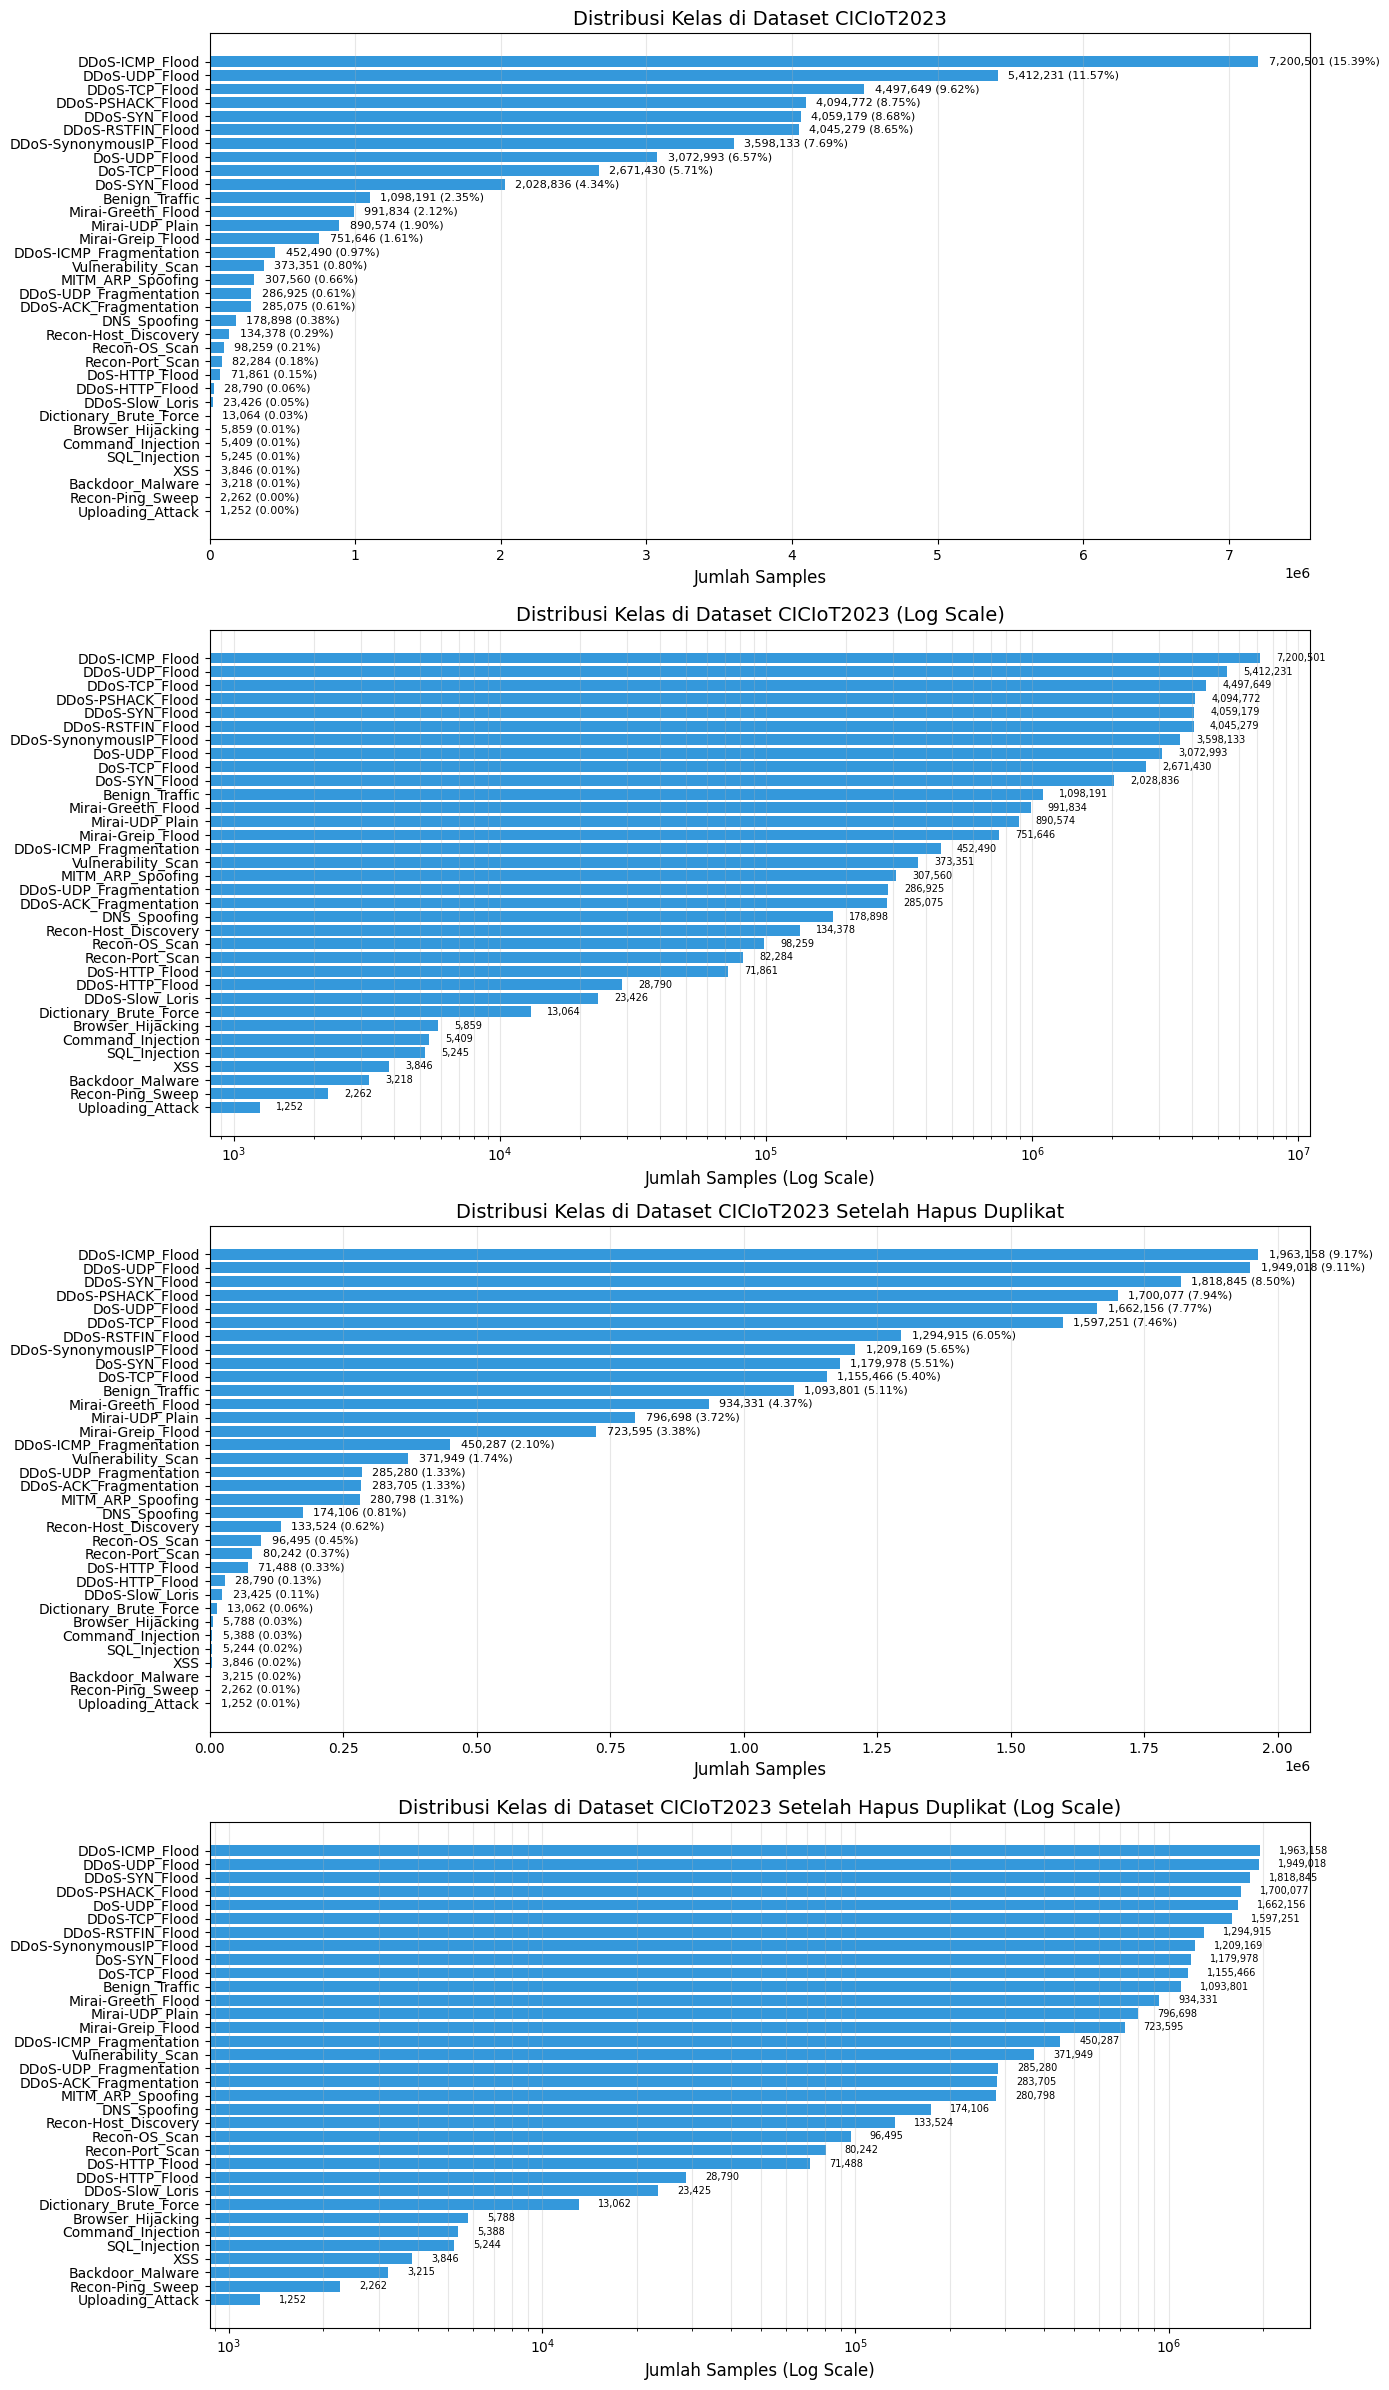


Visualisasi distribusi kelas (revised) tersimpan!


In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 24))

# Explicitly sort class_counts_after for consistent plotting as requested by the user
class_counts_after = class_counts_after.sort_values(ascending=False)

# ========== SUBPLOT 1: BEFORE (Sorted) ==========
ax1 = axes[0]
bars1 = ax1.barh(range(len(class_counts_before)), class_counts_before.values, color='#3498db')
ax1.set_yticks(range(len(class_counts_before)))
ax1.set_yticklabels(class_counts_before.index, fontsize=10)
ax1.set_xlabel('Jumlah Samples', fontsize=12)
ax1.set_title('Distribusi Kelas di Dataset CICIoT2023',
              fontsize=14)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Tambahkan angka di setiap bar
for i, (bar, count) in enumerate(zip(bars1, class_counts_before.values)):
    width = bar.get_width()
    percentage = count / len(df_before) * 100
    ax1.text(width + max(class_counts_before.values)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{count:,} ({percentage:.2f}%)',
            va='center', fontsize=8)

# ========== NEW SUBPLOT 2: BEFORE (Log Scale) ==========
ax2 = axes[1]
bars_before_log = ax2.barh(range(len(class_counts_before)), class_counts_before.values, color='#3498db')
ax2.set_yticks(range(len(class_counts_before)))
ax2.set_yticklabels(class_counts_before.index, fontsize=10)
ax2.set_xlabel('Jumlah Samples (Log Scale)', fontsize=12)
ax2.set_xscale('log')
ax2.set_title('Distribusi Kelas di Dataset CICIoT2023 (Log Scale)',
              fontsize=14)
ax2.grid(axis='x', alpha=0.3, which='both')
ax2.invert_yaxis()
# Tambahkan angka di setiap bar (log scale)
for i, (bar, count) in enumerate(zip(bars_before_log, class_counts_before.values)):
    width = bar.get_width()
    ax2.text(width * 1.15,
            bar.get_y() + bar.get_height()/2,
            f'{count:,}',
            va='center', fontsize=7)


# ========== SUBPLOT 3: AFTER (Sorted) ==========
ax3 = axes[2]
bars2 = ax3.barh(range(len(class_counts_after)), class_counts_after.values, color='#3498db')
ax3.set_yticks(range(len(class_counts_after)))
ax3.set_yticklabels(class_counts_after.index, fontsize=10)
ax3.set_xlabel('Jumlah Samples', fontsize=12)
ax3.set_title('Distribusi Kelas di Dataset CICIoT2023 Setelah Hapus Duplikat',
              fontsize=14)
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

# Tambahkan angka di setiap bar
for i, (bar, count) in enumerate(zip(bars2, class_counts_after.values)):
    width = bar.get_width()
    percentage = count / len(y_all) * 100
    ax3.text(width + max(class_counts_after.values)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{count:,} ({percentage:.2f}%)',
            va='center', fontsize=8)

# ========== SUBPLOT 4: AFTER (Log Scale) ==========
ax4 = axes[3]
bars3 = ax4.barh(range(len(class_counts_after)), class_counts_after.values, color='#3498db')
ax4.set_yticks(range(len(class_counts_after)))
ax4.set_yticklabels(class_counts_after.index, fontsize=10)
ax4.set_xlabel('Jumlah Samples (Log Scale)', fontsize=12)
ax4.set_xscale('log')
ax4.set_title('Distribusi Kelas di Dataset CICIoT2023 Setelah Hapus Duplikat (Log Scale)',
              fontsize=14)
ax4.grid(axis='x', alpha=0.3, which='both')
ax4.invert_yaxis()

# Tambahkan angka di setiap bar (log scale)
for i, (bar, count) in enumerate(zip(bars3, class_counts_after.values)):
    width = bar.get_width()
    ax4.text(width * 1.15,
            bar.get_y() + bar.get_height()/2,
            f'{count:,}',
            va='center', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '1_class_distribution_revised.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi distribusi kelas (revised) tersimpan!")

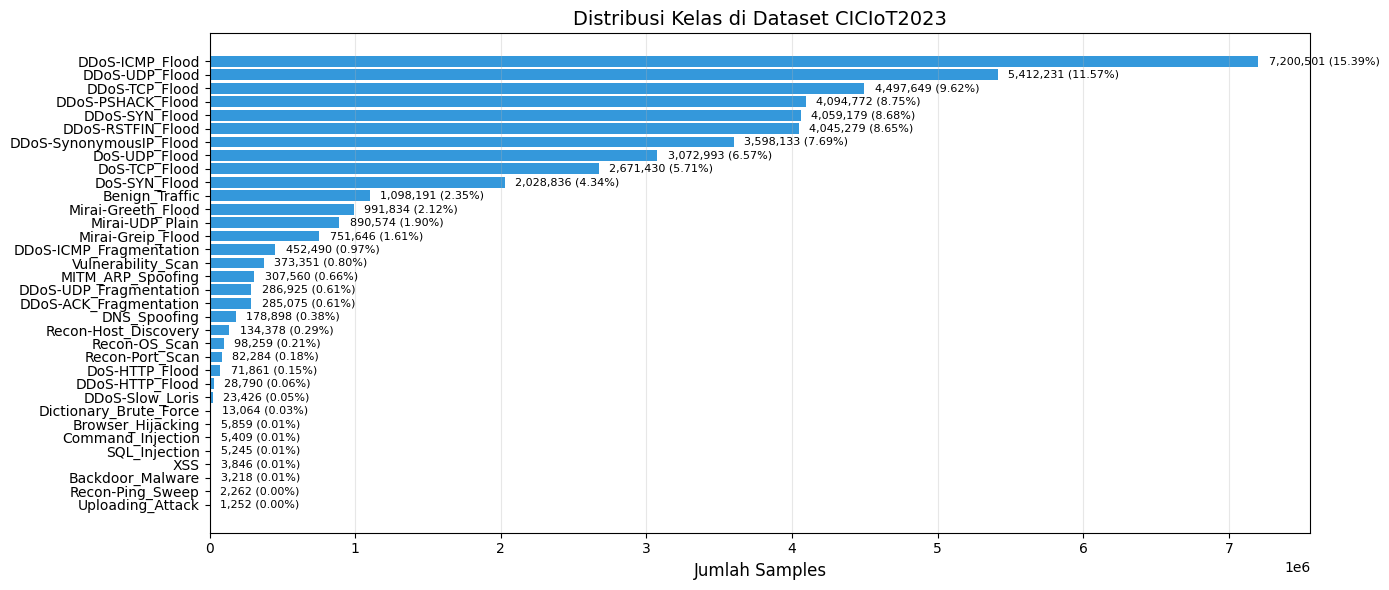


Visualisasi distribusi kelas tersimpan!


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# ========== PLOT 1: BEFORE (Sorted) ==========
bars = ax.barh(range(len(class_counts_before)), class_counts_before.values, color='#3498db')
ax.set_yticks(range(len(class_counts_before)))
ax.set_yticklabels(class_counts_before.index, fontsize=10)
ax.set_xlabel('Jumlah Samples', fontsize=12)
ax.set_title('Distribusi Kelas di Dataset CICIoT2023',
              fontsize=14)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Tambahkan angka di setiap bar
for i, (bar, count) in enumerate(zip(bars, class_counts_before.values)):
    width = bar.get_width()
    percentage = count / len(df_before) * 100
    ax.text(width + max(class_counts_before.values)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{count:,} ({percentage:.2f}%)',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'class_distribution_before.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi distribusi kelas tersimpan!")

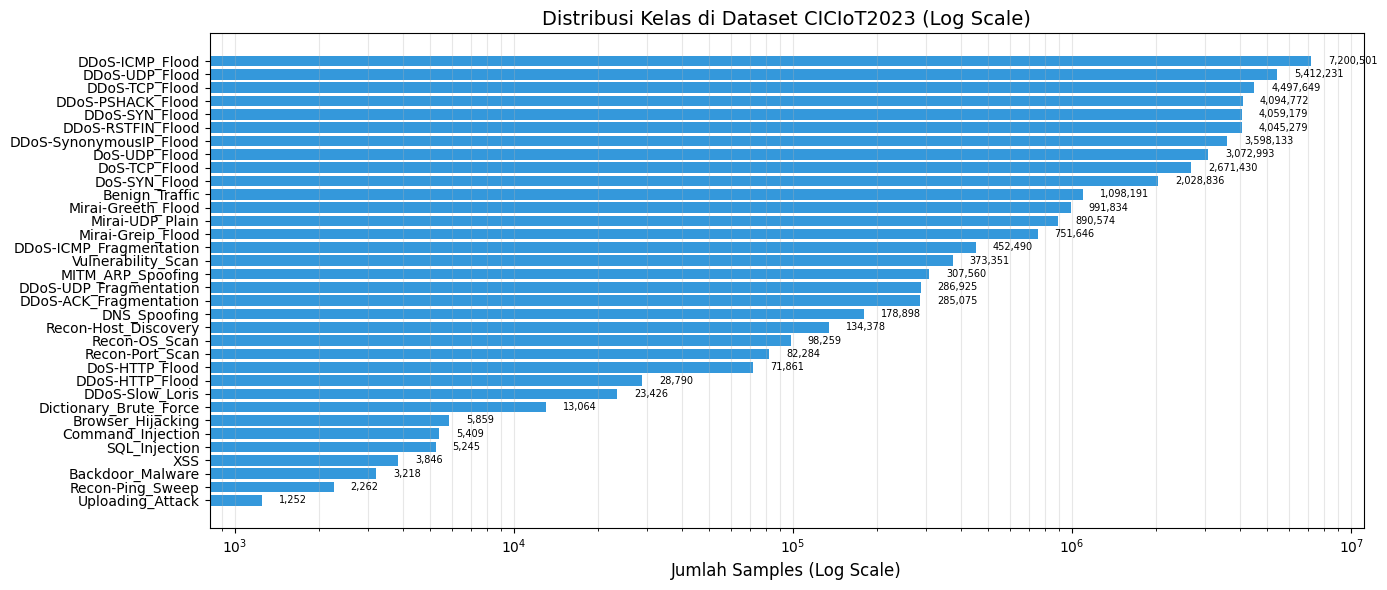


Visualisasi distribusi kelas (Log Scale) tersimpan!


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6)) # Create a single subplot

# ========== PLOT 2: BEFORE (Log Scale) ==========
bars_before_log = ax.barh(range(len(class_counts_before)), class_counts_before.values, color='#3498db')
ax.set_yticks(range(len(class_counts_before)))
ax.set_yticklabels(class_counts_before.index, fontsize=10)
ax.set_xlabel('Jumlah Samples (Log Scale)', fontsize=12)
ax.set_xscale('log')
ax.set_title('Distribusi Kelas di Dataset CICIoT2023 (Log Scale)',
              fontsize=14)
ax.grid(axis='x', alpha=0.3, which='both')
ax.invert_yaxis()
# Tambahkan angka di setiap bar (log scale)
for i, (bar, count) in enumerate(zip(bars_before_log, class_counts_before.values)):
    width = bar.get_width()
    ax.text(width * 1.15,
            bar.get_y() + bar.get_height()/2,
            f'{count:,}',
            va='center', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'class_distribution_before_log_scale.png'), # Change filename for clarity
            dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi distribusi kelas (Log Scale) tersimpan!")

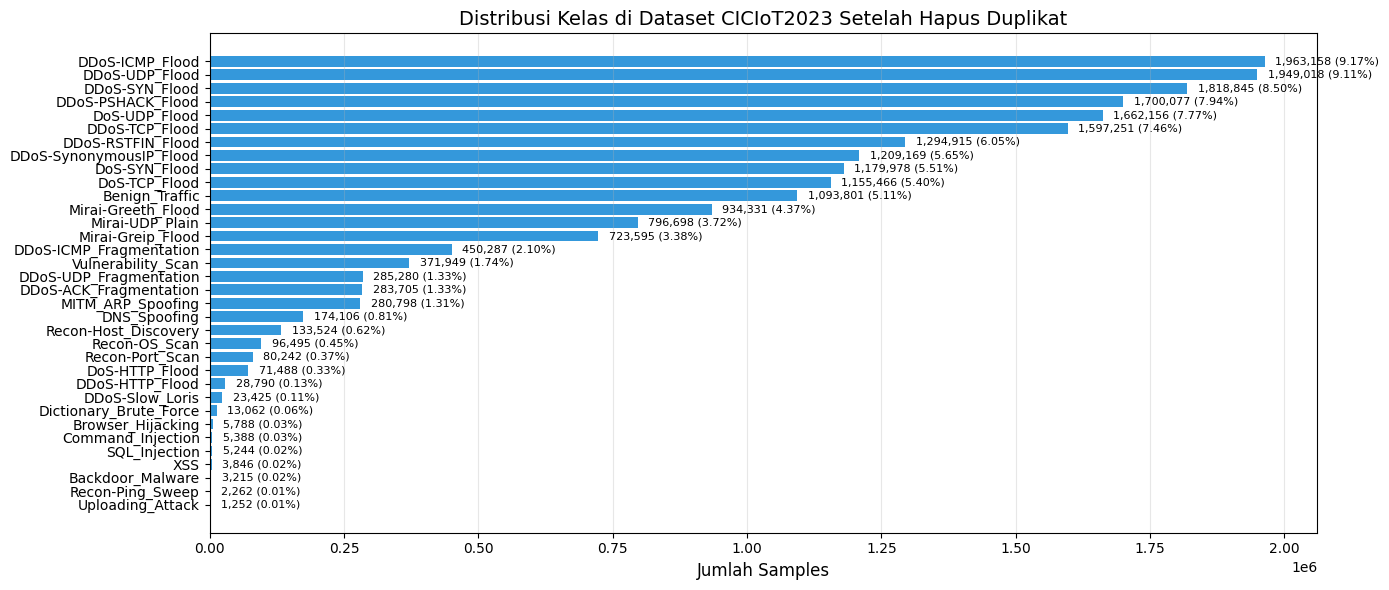


Visualisasi distribusi kelas setelah hapus duplikat tersimpan!


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6)) # Create a single subplot

# ========== SUBPLOT 3: AFTER (Sorted) ==========

bars = ax.barh(range(len(class_counts_after)), class_counts_after.values, color='#3498db')
ax.set_yticks(range(len(class_counts_after)))
ax.set_yticklabels(class_counts_after.index, fontsize=10)
ax.set_xlabel('Jumlah Samples', fontsize=12)
ax.set_title('Distribusi Kelas di Dataset CICIoT2023 Setelah Hapus Duplikat',
              fontsize=14)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Tambahkan angka di setiap bar
for i, (bar, count) in enumerate(zip(bars2, class_counts_after.values)):
    width = bar.get_width()
    percentage = count / len(y_all) * 100
    ax.text(width + max(class_counts_after.values)*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{count:,} ({percentage:.2f}%)',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'class_distribution_after.png'), # Change filename for clarity
            dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi distribusi kelas setelah hapus duplikat tersimpan!")

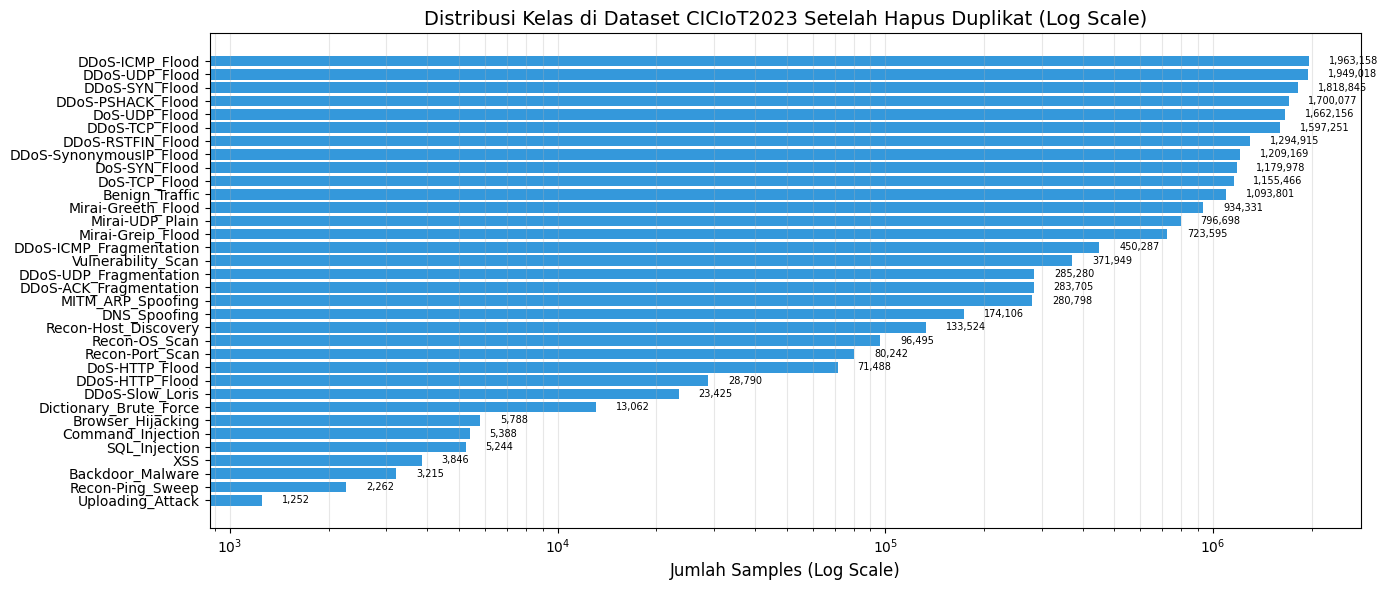


Visualisasi distribusi kelas (Log Scale) setelah hapus duplikat tersimpan!


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6)) # Create a single subplot

# ========== PLOT 4: AFTER (Log Scale) ==========

bars = ax.barh(range(len(class_counts_after)), class_counts_after.values, color='#3498db')
ax.set_yticks(range(len(class_counts_after)))
ax.set_yticklabels(class_counts_after.index, fontsize=10)
ax.set_xlabel('Jumlah Samples (Log Scale)', fontsize=12)
ax.set_xscale('log')
ax.set_title('Distribusi Kelas di Dataset CICIoT2023 Setelah Hapus Duplikat (Log Scale)',
              fontsize=14)
ax.grid(axis='x', alpha=0.3, which='both')
ax.invert_yaxis()

# Tambahkan angka di setiap bar (log scale)
for i, (bar, count) in enumerate(zip(bars3, class_counts_after.values)):
    width = bar.get_width()
    ax.text(width * 1.15,
            bar.get_y() + bar.get_height()/2,
            f'{count:,}',
            va='center', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, 'class_distribution_after_log_scale.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualisasi distribusi kelas (Log Scale) setelah hapus duplikat tersimpan!")

In [ ]:
comparison_data = []
for class_name in class_counts_before.index:
    before_count = class_counts_before[class_name]
    after_count = class_counts_after.get(class_name, 0)
    removed = before_count - after_count
    removed_pct = (removed / before_count * 100) if before_count > 0 else 0

    comparison_data.append({
        'Class': class_name,
        'Before': before_count,
        'After': after_count,
        'Removed': removed,
        'Removed %': round(removed_pct, 2)
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Removed', ascending=False)

print("\nTop 17 kelas dengan duplikat terbanyak:")
print(comparison_df.head(17).to_string(index=False))

# Simpan comparison
comparison_df.to_csv(os.path.join(EDA_DIR, 'class_comparison_before_after.csv'), index=False)

print(f"\nTotal duplicates removed: {(len(df_before) - len(y_all)):,}")
print(f"Percentage: {(len(df_before) - len(y_all))/len(df_before)*100:.2f}%")


Top 17 kelas dengan duplikat terbanyak:
                  Class  Before   After  Removed  Removed %
        DDoS-ICMP_Flood 7200501 1963158  5237343      72.74
         DDoS-UDP_Flood 5412231 1949018  3463213      63.99
         DDoS-TCP_Flood 4497649 1597251  2900398      64.49
      DDoS-RSTFIN_Flood 4045279 1294915  2750364      67.99
      DDoS-PSHACK_Flood 4094772 1700077  2394695      58.48
DDoS-SynonymousIP_Flood 3598133 1209169  2388964      66.39
         DDoS-SYN_Flood 4059179 1818845  2240334      55.19
          DoS-TCP_Flood 2671430 1155466  1515964      56.75
          DoS-UDP_Flood 3072993 1662156  1410837      45.91
          DoS-SYN_Flood 2028836 1179978   848858      41.84
        Mirai-UDP_Plain  890574  796698    93876      10.54
     Mirai-Greeth_Flood  991834  934331    57503       5.80
      Mirai-Greip_Flood  751646  723595    28051       3.73
      MITM_ARP_Spoofing  307560  280798    26762       8.70
           DNS_Spoofing  178898  174106     4792       2.68

###**1.4 Definisi Mapping Kategori (8 Kelas), Pemisahan Fitur dengan Label, dan Label Encoder**

#####1.4.1 Definisi Mapping Kategori (8 Kelas)

In [ ]:
# Mapping dari 34 kelas individual ke 8 kategori
CATEGORY_MAPPING = {
    'DDoS': [
        'DDoS-ICMP_Flood', 'DDoS-UDP_Flood', 'DDoS-TCP_Flood',
        'DDoS-PSHACK_Flood', 'DDoS-SYN_Flood', 'DDoS-RSTFIN_Flood',
        'DDoS-SynonymousIP_Flood', 'DDoS-ICMP_Fragmentation',
        'DDoS-UDP_Fragmentation', 'DDoS-ACK_Fragmentation',
        'DDoS-HTTP_Flood', 'DDoS-Slow_Loris'
    ],
    'DoS': [
        'DoS-UDP_Flood', 'DoS-TCP_Flood', 'DoS-SYN_Flood', 'DoS-HTTP_Flood'
    ],
    'Mirai': [
        'Mirai-Greeth_Flood', 'Mirai-UDP_Plain', 'Mirai-Greip_Flood'
    ],
    'Recon': [
        'Recon-Host_Discovery', 'Recon-OS_Scan', 'Recon-Port_Scan',
        'Recon-Ping_Sweep', 'Vulnerability_Scan'
    ],
    'Web_Based': [
        'SQL_Injection', 'XSS', 'Command_Injection', 'Browser_Hijacking',
        'Uploading_Attack', 'Backdoor_Malware'
    ],
    'Brute_Force': [
        'Dictionary_Brute_Force'
    ],
    'Spoofing': [
        'DNS_Spoofing', 'MITM_ARP_Spoofing'
    ],
    'Benign': [
        'Benign_Traffic'
    ]
}

In [ ]:
# Fungsi untuk mapping label individual ke kategori
def map_to_category(label):
    """Map label individual ke kategori"""
    for category, attacks in CATEGORY_MAPPING.items():
        if label in attacks:
            return category
    return 'Unknown'  # Fallback jika ada label yang tidak terdaftar

# Terapkan mapping ke dataframe
print("Menerapkan kategori grouping...")
df['Category'] = df['Label'].apply(map_to_category)

# Cek hasil mapping
print(f"\nDistribusi Kategori (8 Kelas):")
category_counts = df['Category'].value_counts()
print(category_counts)

print(f"\nPersentase Kategori:")
category_pct = (category_counts / len(df) * 100).round(4)
print(category_pct)

# Hitung imbalance ratio untuk kategori
min_cat = category_counts.min()
max_cat = category_counts.max()
cat_imbalance_ratio = max_cat / min_cat
print(f"\nImbalance Ratio (Kategori): 1:{cat_imbalance_ratio:.0f}")
print(f"Kategori Mayoritas: {category_counts.idxmax()} ({max_cat:,} samples)")
print(f"Kategori Minoritas: {category_counts.idxmin()} ({min_cat:,} samples)")

Menerapkan kategori grouping...

Distribusi Kategori (8 Kelas):
Category
DDoS           12603920
DoS             4069088
Mirai           2454624
Benign          1093801
Recon            684472
Spoofing         454904
Web_Based         24733
Brute_Force       13062
Name: count, dtype: int64

Persentase Kategori:
Category
DDoS           58.9007
DoS            19.0157
Mirai          11.4710
Benign          5.1116
Recon           3.1987
Spoofing        2.1259
Web_Based       0.1156
Brute_Force     0.0610
Name: count, dtype: float64

Imbalance Ratio (Kategori): 1:965
Kategori Mayoritas: DDoS (12,603,920 samples)
Kategori Minoritas: Brute_Force (13,062 samples)


In [ ]:
# Simpan distribusi kategori
category_dist_dict = {
    'counts': {str(k): int(v) for k, v in category_counts.to_dict().items()},
    'percentages': {str(k): float(v) for k, v in category_pct.to_dict().items()},
    'imbalance_ratio': float(cat_imbalance_ratio),
    'majority_class': str(category_counts.idxmax()),
    'minority_class': str(category_counts.idxmin()),
    'mapping': CATEGORY_MAPPING
}

with open(os.path.join(RESULTS_DIR, 'category_distribution.json'), 'w') as f:
    json.dump(category_dist_dict, f, indent=4)

print("\nDistribusi kategori tersimpan!")


Distribusi kategori tersimpan!


#####1.4.2 Memisahkan Fitur dengan Label

In [ ]:
label_col = 'Category'  # PERUBAHAN: Gunakan Category bukan Label
X = df.drop(columns=['Label', 'Category'])  # Drop kedua kolom
y = df[label_col]

print(f"Ukuran fitur (X): {X.shape}")
print(f"Ukuran label (y): {y.shape}")
print(f"Jumlah fitur: {X.shape[1]}")
print(f"Jumlah kategori: {y.nunique()}")

Ukuran fitur (X): (21398604, 39)
Ukuran label (y): (21398604,)
Jumlah fitur: 39
Jumlah kategori: 8


#####1.4.3 Encode Label

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nMapping Label Encoding (8 Kategori):")
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for label_name, label_encoded in sorted(label_mapping.items(), key=lambda x: x[1]):
    count = (y == label_name).sum()
    print(f"  {label_encoded}: {label_name} ({count:,} samples)")


Mapping Label Encoding (8 Kategori):
  0: Benign (1,093,801 samples)
  1: Brute_Force (13,062 samples)
  2: DDoS (12,603,920 samples)
  3: DoS (4,069,088 samples)
  4: Mirai (2,454,624 samples)
  5: Recon (684,472 samples)
  6: Spoofing (454,904 samples)
  7: Web_Based (24,733 samples)


In [ ]:
# Simpan label encoder
with open(os.path.join(PROCESSED_DIR, 'label_encoder_category.pkl'), 'wb') as f:
    pickle.dump(le, f)

# Simpan mapping
label_mapping_readable = {str(k): int(v) for k, v in label_mapping.items()}
with open(os.path.join(RESULTS_DIR, 'label_mapping_category.json'), 'w') as f:
    json.dump(label_mapping_readable, f, indent=4)

# Simpan juga category mapping
with open(os.path.join(RESULTS_DIR, 'category_mapping.json'), 'w') as f:
    json.dump(CATEGORY_MAPPING, f, indent=4)

print("\nLabel encoder untuk kategori tersimpan!")


Label encoder untuk kategori tersimpan!


###**1.5 Split Data (80% Train - 20% Test)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Ukuran train set: {X_train.shape}")
print(f"Ukuran test set: {X_test.shape}")

print(f"\nDistribusi kelas di train set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for idx in train_dist.index:
    class_name = le.inverse_transform([idx])[0]
    print(f"   {idx} ({class_name}): {train_dist[idx]:,}")

print(f"\nDistribusi kelas di test set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for idx in test_dist.index:
    class_name = le.inverse_transform([idx])[0]
    print(f"   {idx} ({class_name}): {test_dist[idx]:,}")

Ukuran train set: (17118883, 39)
Ukuran test set: (4279721, 39)

Distribusi kelas di train set:
   0 (Benign): 875,041
   1 (Brute_Force): 10,450
   2 (DDoS): 10,083,136
   3 (DoS): 3,255,270
   4 (Mirai): 1,963,699
   5 (Recon): 547,578
   6 (Spoofing): 363,923
   7 (Web_Based): 19,786

Distribusi kelas di test set:
   0 (Benign): 218,760
   1 (Brute_Force): 2,612
   2 (DDoS): 2,520,784
   3 (DoS): 813,818
   4 (Mirai): 490,925
   5 (Recon): 136,894
   6 (Spoofing): 90,981
   7 (Web_Based): 4,947


In [ ]:
# Setelah split train-test
del df, X, y # Supaya tidak ada lonjakan RAM
gc.collect()

0

###**1.6 Normalisasi Fitur (StandardScaler)**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Fitur dinormalisasi menggunakan StandardScaler")
print(f"   Mean dari scaled train set: {X_train_scaled.mean():.8f}")
print(f"   Std dari scaled train set: {X_train_scaled.std():.8f}")

# Simpan scaler
with open(os.path.join(PROCESSED_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print("\nScaler tersimpan!")

Fitur dinormalisasi menggunakan StandardScaler
   Mean dari scaled train set: -0.00000000
   Std dari scaled train set: 1.00000000

Scaler tersimpan!


In [ ]:
print("[Validasi Detail Scaling]")

# Cek mean per fitur (seharusnya semua mendekati 0)
means_per_feature = X_train_scaled.mean(axis=0)
print(f"Mean per fitur:")
print(f"  Min: {means_per_feature.min():.10f}")
print(f"  Max: {means_per_feature.max():.10f}")
print(f"  Rata-rata: {means_per_feature.mean():.10f}")

# Cek std per fitur (seharusnya semua mendekati 1)
stds_per_feature = X_train_scaled.std(axis=0)
print(f"\nStd per fitur:")
print(f"  Min: {stds_per_feature.min():.10f}")
print(f"  Max: {stds_per_feature.max():.10f}")
print(f"  Rata-rata: {stds_per_feature.mean():.10f}")

# Cek range data
print(f"\nRange data setelah scaling:")
print(f"  Min value: {X_train_scaled.min():.4f}")
print(f"  Max value: {X_train_scaled.max():.4f}")

# Cek beberapa sample
print(f"\nSample data (5 baris pertama, 5 kolom pertama):")
print(X_train_scaled[:5, :5])

print("\nValidasi selesai!")

[Validasi Detail Scaling]
Mean per fitur:
  Min: -0.0000000000
  Max: 0.0000000000
  Rata-rata: -0.0000000000

Std per fitur:
  Min: 1.0000000000
  Max: 1.0000000000
  Rata-rata: 1.0000000000

Range data setelah scaling:
  Min value: -36.2533
  Max value: 3244.7335

Sample data (5 baris pertama, 5 kolom pertama):
[[-0.6785311   0.50398763 -0.23605963  0.06633375 -0.26477403]
 [ 1.60772293 -0.44740592  1.8461286  -0.33240007 -0.26477403]
 [-1.51069257  3.09869732 -0.04825074 -0.32327748 -0.26477403]
 [-1.10337144 -0.87985753 -0.26193132  0.2792811  -0.13767694]
 [-0.66977152  0.50398763 -0.200606   -0.26962401 -0.26477403]]

Validasi selesai!


 ### **1.7 Menyimpan Data Terproses**

1.7.1 Simpan Sebagai Numpy Arrays

In [ ]:
np.save(os.path.join(PROCESSED_DIR, 'X_train.npy'), X_train_scaled)
np.save(os.path.join(PROCESSED_DIR, 'X_test.npy'), X_test_scaled)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED_DIR, 'y_test.npy'), y_test)

1.7.2 Simpan Nama Fitur

In [ ]:
feature_names = numeric_cols
with open(os.path.join(PROCESSED_DIR, 'feature_names.json'), 'w') as f:
    json.dump(feature_names, f)

In [ ]:
print("Data terproses berhasil disimpan!")
print(f"   Lokasi: {PROCESSED_DIR}")
print(f"   File:")
print(f"      - X_train.npy ({X_train_scaled.nbytes / 1024**2:.2f} MB)")
print(f"      - X_test.npy ({X_test_scaled.nbytes / 1024**2:.2f} MB)")
print(f"      - y_train.npy ({y_train.nbytes / 1024**2:.2f} MB)")
print(f"      - y_test.npy ({y_test.nbytes / 1024**2:.2f} MB)")
print(f"      - scaler.pkl")
print(f"      - label_encoder.pkl")
print(f"      - feature_names.json")

Data terproses berhasil disimpan!
   Lokasi: /content/drive/My Drive/Baseline/Processed_Data/
   File:
      - X_train.npy (5093.66 MB)
      - X_test.npy (1273.42 MB)
      - y_train.npy (130.61 MB)
      - y_test.npy (32.65 MB)
      - scaler.pkl
      - label_encoder.pkl
      - feature_names.json


###**Ringkasan**

In [ ]:
summary = {
    'nama_dataset': 'CICIoT2023',
    'total_samples': int(X_train.shape[0] + X_test.shape[0]),
    'jumlah_fitur': len(feature_names),
    'jumlah_kelas_original': 34,
    'jumlah_kategori': len(le.classes_),
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'train_test_ratio': '80:20',
    'normalisasi': 'StandardScaler',
    'label_encoding': 'LabelEncoder',
    'feature_names': feature_names,
    'category_names': le.classes_.tolist(),
    'category_mapping': CATEGORY_MAPPING,
    'imbalance_ratio': float(cat_imbalance_ratio)
}

with open(os.path.join(RESULTS_DIR, 'preprocessing_summary_category.json'), 'w') as f:
    json.dump(summary, f, indent=4)

print("Preprocessing selesai!")
print(f"\nDataset: {summary['nama_dataset']}")
print(f"Tipe Klasifikasi: {summary['klasifikasi_type']}")
print(f"Total Samples: {summary['total_samples']:,}")
print(f"Jumlah Fitur: {summary['jumlah_fitur']}")
print(f"Jumlah Kategori: {summary['jumlah_kategori']}")  # UBAH
print(f"Train Samples: {summary['train_samples']:,}")
print(f"Test Samples: {summary['test_samples']:,}")
print(f"Imbalance Ratio: 1:{summary['imbalance_ratio']:.0f}")

Preprocessing selesai!

Dataset: CICIoT2023
Tipe Klasifikasi: Multiclass_Grouping
Total Samples: 21,398,604
Jumlah Fitur: 39
Jumlah Kategori: 8
Train Samples: 17,118,883
Test Samples: 4,279,721
Imbalance Ratio: 1:965


In [ ]:
# Cek RAM Sistem Tersisa
mem = psutil.virtual_memory()
print(f"RAM Sistem Tersisa: {mem.available / (1024**3):.2f} GB")

RAM Sistem Tersisa: 28.64 GB
